# 03 — Modelado · Clasificación · Austin Animal Center
**Objetivo:** Entrenar, comparar y seleccionar el mejor modelo de clasificación multiclase.

**Input:** `data/processed/splits_procesados.npz`

### Índice
1. Carga de splits y configuración global
2. Funciones auxiliares (métricas, plots)
3. Baseline — los 4 modelos sin tuning
4. Comparativa baseline
5. Tuning de hiperparámetros
6. Evaluación final en test
7. Feature importance — RF y XGBoost
8. Curvas ROC / Precision-Recall
9. Tabla comparativa final

---
## 1. Carga de splits y configuración global

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier
from sklearn.svm             import SVC
from xgboost                 import XGBClassifier

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics         import (classification_report, confusion_matrix,
                                     f1_score, roc_auc_score,
                                     RocCurveDisplay, PrecisionRecallDisplay,
                                     roc_curve, precision_recall_curve,
                                     average_precision_score)
from sklearn.preprocessing   import label_binarize
import joblib

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 130

# ── Clases y paleta ──────────────────────────────────────────────────────────
CLASS_ORDER = ["Adoption", "Transfer", "Return to Owner", "At Risk"]
PALETTE = {
    "Adoption":        "#2ecc71",
    "Transfer":        "#3498db",
    "Return to Owner": "#f39c12",
    "At Risk":         "#e74c3c",
}
COLORS = [PALETTE[c] for c in CLASS_ORDER]
SEED   = 42

print("✅ Imports OK")

✅ Imports OK


In [2]:
# ── Carga de splits ──────────────────────────────────────────────────────────
data = np.load("../data/processed/splits_procesados.npz")

X_train      = data["X_train_prep"]   # sin SMOTE  → para class_weight
X_train_bal  = data["X_train_bal"]    # con SMOTE  → balanceado
X_val        = data["X_val_prep"]
X_test       = data["X_test_prep"]
y_train      = data["y_train"]
y_train_bal  = data["y_train_bal"]
y_val        = data["y_val"]
y_test       = data["y_test"]

print("Shapes cargados:")
print(f"  X_train:     {X_train.shape}     y_train:     {y_train.shape}")
print(f"  X_train_bal: {X_train_bal.shape}  y_train_bal: {y_train_bal.shape}")
print(f"  X_val:       {X_val.shape}      y_val:       {y_val.shape}")
print(f"  X_test:      {X_test.shape}      y_test:      {y_test.shape}")

# Índice At Risk (para métricas específicas)
AT_RISK_IDX = 0   # Ajustar según el orden del LabelEncoder del notebook 02
print(f"\nÍndice At Risk: {AT_RISK_IDX}  ← verificar con le_target.transform(['At Risk'])")

Shapes cargados:
  X_train:     (66507, 30)     y_train:     (66507,)
  X_train_bal: (130352, 30)  y_train_bal: (130352,)
  X_val:       (22170, 30)      y_val:       (22170,)
  X_test:      (22170, 30)      y_test:      (22170,)

Índice At Risk: 0  ← verificar con le_target.transform(['At Risk'])


---
## 2. Funciones auxiliares

In [3]:
def eval_model(model, X_tr, y_tr, X_vl, y_vl, name="modelo"):
    """
    Entrena el modelo y devuelve un dict con métricas en validación.
    Incluye F1-macro, Accuracy y Recall de At Risk.
    """
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_vl)

    f1_mac   = f1_score(y_vl, y_pred, average="macro",    zero_division=0)
    f1_wr    = f1_score(y_vl, y_pred, average="weighted",  zero_division=0)
    acc      = (y_pred == y_vl).mean()

    report   = classification_report(y_vl, y_pred,
                                     target_names=CLASS_ORDER,
                                     output_dict=True,
                                     zero_division=0)
    rec_risk = report["At Risk"]["recall"]
    f1_risk  = report["At Risk"]["f1-score"]

    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  F1-macro:        {f1_mac:.4f}")
    print(f"  F1-weighted:     {f1_wr:.4f}")
    print(f"  Accuracy:        {acc:.4f}")
    print(f"  Recall At Risk:  {rec_risk:.4f}  {'✅' if rec_risk >= 0.55 else '⚠️  < 0.55'}")
    print(f"  F1 At Risk:      {f1_risk:.4f}")
    print()
    print(classification_report(y_vl, y_pred,
                                 target_names=CLASS_ORDER,
                                 zero_division=0))
    return {
        "name":      name,
        "model":     model,
        "f1_macro":  round(f1_mac,  4),
        "f1_weighted": round(f1_wr, 4),
        "accuracy":  round(acc,     4),
        "recall_at_risk": round(rec_risk, 4),
        "f1_at_risk": round(f1_risk, 4),
    }


def plot_confusion(model, X_vl, y_vl, title="Confusion Matrix"):
    """Matriz de confusión normalizada en porcentaje."""
    y_pred = model.predict(X_vl)
    cm     = confusion_matrix(y_vl, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=13, fontweight="bold")

    for ax, data, fmt, ttl in zip(
        axes,
        [cm, cm_pct],
        ["d", ".1f"],
        ["Conteo absoluto", "Normalizada (%)"]
    ):
        sns.heatmap(data, annot=True, fmt=fmt, cmap="Blues",
                    xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER,
                    linewidths=0.5, ax=ax,
                    cbar_kws={"shrink": 0.8})
        ax.set_xlabel("Predicho")
        ax.set_ylabel("Real")
        ax.set_title(ttl, fontweight="bold")
        ax.tick_params(axis="x", rotation=30)
        ax.tick_params(axis="y", rotation=0)

    plt.tight_layout()
    plt.show()

print("✅ Funciones auxiliares definidas")

✅ Funciones auxiliares definidas


---
## 3. Baseline — los 4 modelos sin tuning

Entrenamos cada modelo con sus parámetros por defecto para establecer
un punto de partida antes del tuning.

Probamos **dos estrategias de balanceo**:
- `cw` → `class_weight='balanced'` (penaliza errores en clases minoritarias)
- `smote` → train balanceado con SMOTE (datos sintéticos generados en el notebook 02)

In [4]:
results_baseline = []

# ── Logistic Regression ──────────────────────────────────────────────────────
lr_cw = eval_model(
    LogisticRegression(class_weight="balanced", max_iter=1000, random_state=SEED),
    X_train, y_train, X_val, y_val,
    name="LR · class_weight"
)
results_baseline.append(lr_cw)

lr_sm = eval_model(
    LogisticRegression(max_iter=1000, random_state=SEED),
    X_train_bal, y_train_bal, X_val, y_val,
    name="LR · SMOTE"
)
results_baseline.append(lr_sm)


  LR · class_weight
  F1-macro:        0.4529
  F1-weighted:     0.4974
  Accuracy:        0.4934
  Recall At Risk:  0.4287  ⚠️  < 0.55
  F1 At Risk:      0.4304

                 precision    recall  f1-score   support

       Adoption       0.66      0.42      0.52     10863
       Transfer       0.19      0.52      0.28       821
Return to Owner       0.48      0.76      0.59      4232
        At Risk       0.43      0.43      0.43      6254

       accuracy                           0.49     22170
      macro avg       0.44      0.53      0.45     22170
   weighted avg       0.55      0.49      0.50     22170


  LR · SMOTE
  F1-macro:        0.4513
  F1-weighted:     0.4944
  Accuracy:        0.4907
  Recall At Risk:  0.4296  ⚠️  < 0.55
  F1 At Risk:      0.4293

                 precision    recall  f1-score   support

       Adoption       0.66      0.42      0.51     10863
       Transfer       0.19      0.53      0.28       821
Return to Owner       0.48      0.76      0.59  

In [5]:
# ── Random Forest ────────────────────────────────────────────────────────────
rf_cw = eval_model(
    RandomForestClassifier(n_estimators=200, class_weight="balanced",
                           n_jobs=-1, random_state=SEED),
    X_train, y_train, X_val, y_val,
    name="RF · class_weight"
)
results_baseline.append(rf_cw)

rf_sm = eval_model(
    RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=SEED),
    X_train_bal, y_train_bal, X_val, y_val,
    name="RF · SMOTE"
)
results_baseline.append(rf_sm)


  RF · class_weight
  F1-macro:        0.4515
  F1-weighted:     0.5341
  Accuracy:        0.5272
  Recall At Risk:  0.4029  ⚠️  < 0.55
  F1 At Risk:      0.4452

                 precision    recall  f1-score   support

       Adoption       0.65      0.55      0.60     10863
       Transfer       0.14      0.33      0.20       821
Return to Owner       0.48      0.68      0.56      4232
        At Risk       0.50      0.40      0.45      6254

       accuracy                           0.53     22170
      macro avg       0.44      0.49      0.45     22170
   weighted avg       0.56      0.53      0.53     22170


  RF · SMOTE
  F1-macro:        0.4643
  F1-weighted:     0.5445
  Accuracy:        0.5437
  Recall At Risk:  0.4161  ⚠️  < 0.55
  F1 At Risk:      0.4542

                 precision    recall  f1-score   support

       Adoption       0.65      0.58      0.61     10863
       Transfer       0.19      0.27      0.22       821
Return to Owner       0.48      0.69      0.57  

In [7]:
# ── SVM ──────────────────────────────────────────────────────────────────────
# ⚠️  SVM es lento con datasets grandes — usamos una muestra de 30k para baseline
# En el tuning se puede usar LinearSVC o aumentar la muestra.
sample_idx  = np.random.default_rng(SEED).choice(len(X_train),     size=30_000, replace=False)
sample_bal  = np.random.default_rng(SEED).choice(len(X_train_bal), size=30_000, replace=False)

svm_cw = eval_model(
    SVC(class_weight="balanced", kernel="rbf", probability=True, random_state=SEED),
    X_train[sample_idx], y_train[sample_idx], X_val, y_val,
    name="SVM · class_weight (muestra 30k)"
)
results_baseline.append(svm_cw)

svm_sm = eval_model(
    SVC(kernel="rbf", probability=True, random_state=SEED),
    X_train_bal[sample_bal], y_train_bal[sample_bal], X_val, y_val,
    name="SVM · SMOTE (muestra 30k)"
)
results_baseline.append(svm_sm)


  SVM · class_weight (muestra 30k)
  F1-macro:        0.4622
  F1-weighted:     0.5207
  Accuracy:        0.5156
  Recall At Risk:  0.3710  ⚠️  < 0.55
  F1 At Risk:      0.4187

                 precision    recall  f1-score   support

       Adoption       0.66      0.51      0.57     10863
       Transfer       0.18      0.53      0.27       821
Return to Owner       0.48      0.75      0.59      4232
        At Risk       0.48      0.37      0.42      6254

       accuracy                           0.52     22170
      macro avg       0.45      0.54      0.46     22170
   weighted avg       0.56      0.52      0.52     22170


  SVM · SMOTE (muestra 30k)
  F1-macro:        0.4620
  F1-weighted:     0.5193
  Accuracy:        0.5143
  Recall At Risk:  0.3740  ⚠️  < 0.55
  F1 At Risk:      0.4202

                 precision    recall  f1-score   support

       Adoption       0.66      0.50      0.57     10863
       Transfer       0.18      0.53      0.27       821
Return to Owner   

In [ ]:
# ── XGBoost ──────────────────────────────────────────────────────────────────
# scale_pos_weight no aplica a multiclase directamente;
# usamos sample_weight para simular class_weight="balanced"
from sklearn.utils.class_weight import compute_sample_weight

sw_train = compute_sample_weight("balanced", y_train)

xgb_cw = eval_model(
    XGBClassifier(n_estimators=200, use_label_encoder=False,
                  eval_metric="mlogloss", n_jobs=-1, random_state=SEED),
    X_train, y_train, X_val, y_val,
    name="XGBoost · sample_weight"
)
# XGBoost no acepta sample_weight en eval_model genérico → fit manual
xgb_cw["model"].fit(X_train, y_train, sample_weight=sw_train)
results_baseline[-1] = xgb_cw  # actualizar con modelo re-entrenado

xgb_sm = eval_model(
    XGBClassifier(n_estimators=200, use_label_encoder=False,
                  eval_metric="mlogloss", n_jobs=-1, random_state=SEED),
    X_train_bal, y_train_bal, X_val, y_val,
    name="XGBoost · SMOTE"
)
results_baseline.append(xgb_sm)


  XGBoost · sample_weight
  F1-macro:        0.5010
  F1-weighted:     0.5987
  Accuracy:        0.6184
  Recall At Risk:  0.3601  ⚠️  < 0.55
  F1 At Risk:      0.4502

                 precision    recall  f1-score   support

       Adoption       0.63      0.81      0.71     10863
       Transfer       0.40      0.17      0.24       821
Return to Owner       0.61      0.60      0.61      4232
        At Risk       0.60      0.36      0.45      6254

       accuracy                           0.62     22170
      macro avg       0.56      0.49      0.50     22170
   weighted avg       0.61      0.62      0.60     22170


  XGBoost · SMOTE
  F1-macro:        0.4993
  F1-weighted:     0.5765
  Accuracy:        0.5789
  Recall At Risk:  0.3957  ⚠️  < 0.55
  F1 At Risk:      0.4686

                 precision    recall  f1-score   support

       Adoption       0.67      0.64      0.65     10863
       Transfer       0.24      0.34      0.28       821
Return to Owner       0.50      0.75 

---
## 4. Comparativa baseline

COMPARATIVA BASELINE — ordenada por F1-macro
                            name  f1_macro  f1_weighted  accuracy  recall_at_risk  f1_at_risk
         XGBoost · sample_weight    0.5010       0.5987    0.6184          0.3601      0.4502
                 XGBoost · SMOTE    0.4993       0.5765    0.5789          0.3957      0.4686
                      RF · SMOTE    0.4643       0.5445    0.5437          0.4161      0.4542
SVM · class_weight (muestra 30k)    0.4622       0.5207    0.5156          0.3710      0.4187
               LR · class_weight    0.4529       0.4974    0.4934          0.4287      0.4304
               RF · class_weight    0.4515       0.5341    0.5272          0.4029      0.4452
                      LR · SMOTE    0.4513       0.4944    0.4907          0.4296      0.4293


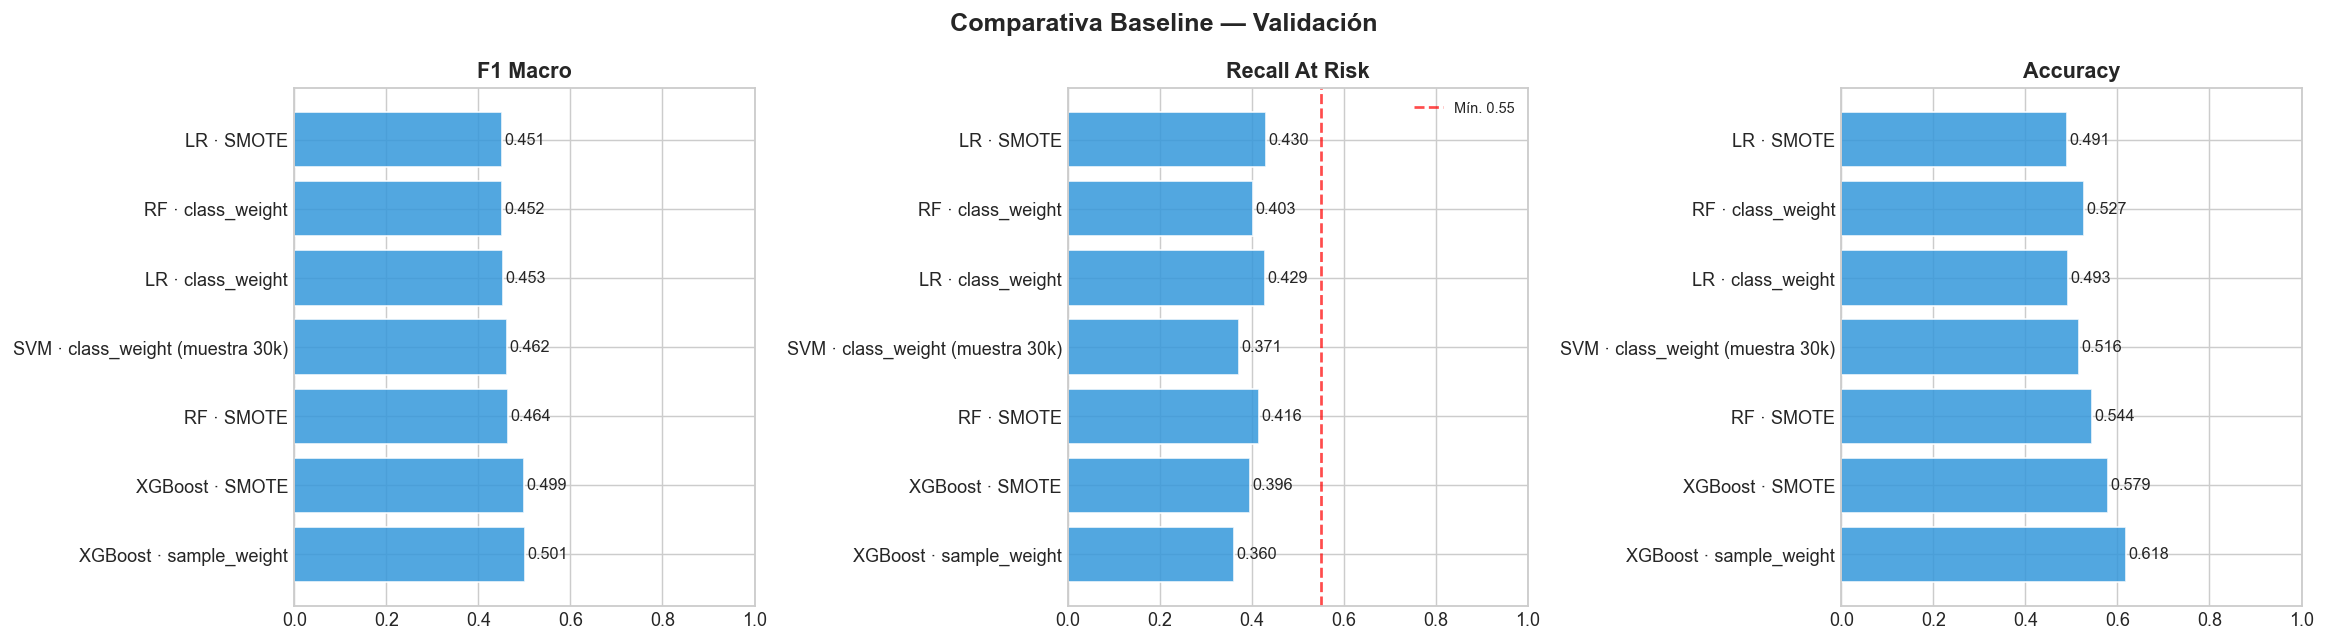

In [ ]:
df_base = pd.DataFrame([
    {k: v for k, v in r.items() if k != "model"}
    for r in results_baseline
]).sort_values("f1_macro", ascending=False)

print("COMPARATIVA BASELINE — ordenada por F1-macro")
print(df_base.to_string(index=False))

# ── Gráfico comparativo ───────────────────────────────────────────────────────
metrics = ["f1_macro", "recall_at_risk", "accuracy"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Comparativa Baseline — Validación", fontsize=14, fontweight="bold")

for ax, metric in zip(axes, metrics):
    bars = ax.barh(df_base["name"], df_base[metric],
                   color="#3498db", edgecolor="white", alpha=0.85)
    ax.set_title(metric.replace("_", " ").title(), fontweight="bold")
    ax.set_xlim(0, 1)
    if metric == "recall_at_risk":
        ax.axvline(0.55, color="red", linestyle="--", alpha=0.7, label="Mín. 0.55")
        ax.legend(fontsize=8)
    for bar, v in zip(bars, df_base[metric]):
        ax.text(v + 0.005, bar.get_y() + bar.get_height()/2,
                f"{v:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("../reports/figures/16_baseline_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 5. Tuning de hiperparámetros — RandomizedSearchCV

Seleccionamos la mejor variante de cada modelo del baseline
y buscamos hiperparámetros con `RandomizedSearchCV` + `StratifiedKFold(k=5)`.

**Métrica objetivo:** `f1_macro` — equilibra rendimiento entre las 4 clases.

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# ── Logistic Regression ──────────────────────────────────────────────────────
param_lr = {
    "C":       [0.01, 0.1, 1, 10, 100],
    "solver":  ["lbfgs", "saga"],
    "penalty": ["l2"],
}
search_lr = RandomizedSearchCV(
    LogisticRegression(class_weight="balanced", max_iter=2000, random_state=SEED),
    param_lr, n_iter=15, scoring="f1_macro", cv=cv,
    n_jobs=-1, random_state=SEED, verbose=1
)
search_lr.fit(X_train, y_train)
print(f"\nLR  — mejor params: {search_lr.best_params_}  |  CV F1-macro: {search_lr.best_score_:.4f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits

LR  — mejor params: {'solver': 'lbfgs', 'penalty': 'l2', 'C': 10}  |  CV F1-macro: 0.4583


In [ ]:
# ── Random Forest ────────────────────────────────────────────────────────────
param_rf = {
    "n_estimators":      [200, 400, 600],
    "max_depth":         [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4],
    "max_features":      ["sqrt", "log2"],
}
search_rf = RandomizedSearchCV(
    RandomForestClassifier(class_weight="balanced", n_jobs=-1, random_state=SEED),
    param_rf, n_iter=20, scoring="f1_macro", cv=cv,
    n_jobs=-1, random_state=SEED, verbose=1
)
search_rf.fit(X_train, y_train)
print(f"\nRF  — mejor params: {search_rf.best_params_}  |  CV F1-macro: {search_rf.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits


In [8]:
# ── SVM ──────────────────────────────────────────────────────────────────────
# Usamos muestra de 30k para que el tuning sea viable en tiempo
param_svm = {
    "C":     [0.1, 1, 10, 100],
    "gamma": ["scale", "auto", 0.01, 0.001],
}
search_svm = RandomizedSearchCV(
    SVC(class_weight="balanced", kernel="rbf", probability=True, random_state=SEED),
    param_svm, n_iter=12, scoring="f1_macro", cv=cv,
    n_jobs=-1, random_state=SEED, verbose=1
)
search_svm.fit(X_train[sample_idx], y_train[sample_idx])
print(f"\nSVM — mejor params: {search_svm.best_params_}  |  CV F1-macro: {search_svm.best_score_:.4f}")

NameError: name 'cv' is not defined

In [ ]:
# ── XGBoost ──────────────────────────────────────────────────────────────────
param_xgb = {
    "n_estimators":    [200, 400, 600],
    "max_depth":       [3, 5, 7, 9],
    "learning_rate":   [0.01, 0.05, 0.1, 0.2],
    "subsample":       [0.6, 0.8, 1.0],
    "colsample_bytree":[0.6, 0.8, 1.0],
    "min_child_weight":[1, 3, 5],
}
search_xgb = RandomizedSearchCV(
    XGBClassifier(use_label_encoder=False, eval_metric="mlogloss",
                  n_jobs=-1, random_state=SEED),
    param_xgb, n_iter=25, scoring="f1_macro", cv=cv,
    n_jobs=-1, random_state=SEED, verbose=1
)
search_xgb.fit(X_train_bal, y_train_bal)
print(f"\nXGB — mejor params: {search_xgb.best_params_}  |  CV F1-macro: {search_xgb.best_score_:.4f}")

---
## 6. Evaluación final en test

⚠️ **Solo se ejecuta una vez.** Usamos test únicamente para reportar
el rendimiento final — nunca para tomar decisiones de diseño.

In [ ]:
best_models = {
    "Logistic Regression": search_lr.best_estimator_,
    "Random Forest":       search_rf.best_estimator_,
    "SVM":                 search_svm.best_estimator_,
    "XGBoost":             search_xgb.best_estimator_,
}

results_test = []
for name, model in best_models.items():
    y_pred   = model.predict(X_test)
    f1_mac   = f1_score(y_test, y_pred, average="macro",   zero_division=0)
    acc      = (y_pred == y_test).mean()
    report   = classification_report(y_test, y_pred,
                                     target_names=CLASS_ORDER,
                                     output_dict=True, zero_division=0)
    rec_risk = report["At Risk"]["recall"]
    f1_risk  = report["At Risk"]["f1-score"]
    results_test.append({
        "Modelo":          name,
        "F1-macro":        round(f1_mac,  4),
        "Accuracy":        round(acc,     4),
        "Recall At Risk":  round(rec_risk,4),
        "F1 At Risk":      round(f1_risk, 4),
    })
    print(f"\n{'='*55}  {name}")
    print(classification_report(y_test, y_pred,
                                 target_names=CLASS_ORDER, zero_division=0))

df_test = pd.DataFrame(results_test).sort_values("F1-macro", ascending=False)

In [ ]:
# Matrices de confusión — todos los modelos tuneados
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle("Matrices de confusión — Test (modelos tuneados)", fontsize=14, fontweight="bold")
axes = axes.flatten()

for ax, (name, model) in zip(axes, best_models.items()):
    y_pred = model.predict(X_test)
    cm_pct = confusion_matrix(y_test, y_pred, normalize="true") * 100
    sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap="Blues",
                xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER,
                linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.7},
                annot_kws={"size": 9})
    ax.set_title(name, fontweight="bold")
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Real")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("../reports/figures/17_confusion_matrices_test.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 7. Feature Importance — RF y XGBoost

In [ ]:
# Recuperar nombres de features del preprocesador
preprocessor = joblib.load("../models/preprocessor.pkl")
feature_names = preprocessor.get_feature_names_out()

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle("Feature Importance — Top 20", fontsize=14, fontweight="bold")

for ax, (name, model) in zip(axes, [
    ("Random Forest", search_rf.best_estimator_),
    ("XGBoost",       search_xgb.best_estimator_),
]):
    importances = pd.Series(model.feature_importances_, index=feature_names)
    top20       = importances.nlargest(20).sort_values()

    bars = ax.barh(top20.index, top20.values,
                   color="#3498db", edgecolor="white", alpha=0.85)
    ax.set_title(name, fontweight="bold")
    ax.set_xlabel("Importancia")
    for bar, v in zip(bars, top20.values):
        ax.text(v + 0.0005, bar.get_y() + bar.get_height()/2,
                f"{v:.4f}", va="center", fontsize=8)

plt.tight_layout()
plt.savefig("../reports/figures/18_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 8. Curvas ROC y Precision-Recall

Evaluamos la capacidad discriminante de cada modelo para cada clase,
especialmente para **At Risk** que es la clase crítica.

In [ ]:
# Binarizar y_test para curvas OvR
y_test_bin = label_binarize(y_test, classes=list(range(len(CLASS_ORDER))))

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle("Curvas ROC y Precision-Recall — Test (OvR)", fontsize=14, fontweight="bold")

for col, (name, model) in enumerate(best_models.items()):
    y_prob = model.predict_proba(X_test)

    # ── ROC ──────────────────────────────────────────────────────────────────
    ax_roc = axes[0][col]
    for i, clase in enumerate(CLASS_ORDER):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        auc         = roc_auc_score(y_test_bin[:, i], y_prob[:, i])
        lw          = 2.5 if clase == "At Risk" else 1.2
        ax_roc.plot(fpr, tpr, color=PALETTE[clase],
                    label=f"{clase} (AUC={auc:.2f})", linewidth=lw)
    ax_roc.plot([0,1],[0,1], "k--", linewidth=0.8)
    ax_roc.set_title(f"ROC — {name}", fontweight="bold", fontsize=9)
    ax_roc.set_xlabel("FPR"); ax_roc.set_ylabel("TPR")
    ax_roc.legend(fontsize=7)

    # ── Precision-Recall ─────────────────────────────────────────────────────
    ax_pr = axes[1][col]
    for i, clase in enumerate(CLASS_ORDER):
        prec, rec, _ = precision_recall_curve(y_test_bin[:, i], y_prob[:, i])
        ap           = average_precision_score(y_test_bin[:, i], y_prob[:, i])
        lw           = 2.5 if clase == "At Risk" else 1.2
        ax_pr.plot(rec, prec, color=PALETTE[clase],
                   label=f"{clase} (AP={ap:.2f})", linewidth=lw)
    ax_pr.set_title(f"PR — {name}", fontweight="bold", fontsize=9)
    ax_pr.set_xlabel("Recall"); ax_pr.set_ylabel("Precision")
    ax_pr.legend(fontsize=7)

plt.tight_layout()
plt.savefig("../reports/figures/19_roc_pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 9. Tabla comparativa final

In [ ]:
print("=" * 65)
print("TABLA COMPARATIVA FINAL — TEST")
print("=" * 65)
print(df_test.to_string(index=False))

# ── Gráfico final ─────────────────────────────────────────────────────────────
metrics_final = ["F1-macro", "Recall At Risk", "Accuracy", "F1 At Risk"]
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle("Comparativa Final — Test (modelos tuneados)", fontsize=14, fontweight="bold")

model_colors = ["#3498db", "#2ecc71", "#f39c12", "#e74c3c"]
for ax, metric in zip(axes, metrics_final):
    bars = ax.bar(df_test["Modelo"], df_test[metric],
                  color=model_colors, edgecolor="white", linewidth=1.5)
    ax.set_title(metric, fontweight="bold")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=25)
    if metric == "Recall At Risk":
        ax.axhline(0.55, color="red", linestyle="--", alpha=0.7, label="Mín. 0.55")
        ax.legend(fontsize=8)
    for bar, v in zip(bars, df_test[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f"{v:.3f}", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("../reports/figures/20_final_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Mejor modelo ──────────────────────────────────────────────────────────────
best_row = df_test.iloc[0]
print(f"\n🏆 MEJOR MODELO: {best_row['Modelo']}")
print(f"   F1-macro:       {best_row['F1-macro']}")
print(f"   Recall At Risk: {best_row['Recall At Risk']}  {'✅' if best_row['Recall At Risk'] >= 0.55 else '⚠️  no alcanza 0.55'}")
print(f"   Accuracy:       {best_row['Accuracy']}")

In [ ]:
# ── Guardar mejor modelo ──────────────────────────────────────────────────────
best_name  = df_test.iloc[0]["Modelo"]
best_model = best_models[best_name]

joblib.dump(best_model, "../models/best_model.pkl")
print(f"✅ Modelo guardado: ../models/best_model.pkl  ({best_name})")